In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform

import sklearn
sklearn.set_config(display="text")

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [9]:
base_path = r"C:\kdt_0900_lsu\ml\resource\datasets"
file_name = r"fish.csv"

file_path = os.path.join(base_path, file_name)

In [10]:
fish_df = pd.read_csv(file_path)
fish_df

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...
154,Smelt,12.2,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,14.3,15.2,2.8728,2.0672


### fish 종류
    Bream: 도미류
    Roach: 잉어과 담수어
    Whitefish: 송어
    Parkki: 청돔
    Perch: 농어
    Pike: 강꼬치고기
    Smelt: 빙어

### fish 컬럼 설명
| 컬럼명 (Column) | 설명 (Description) | 단위 (Unit) |
| :--- | :--- | :--- |
| **Species** | 물고기의 종류 (예: Bream, Smelt 등) | 분류 (텍스트) |
| **Weight** | 물고기의 무게 | 그램 (g) |
| **Length** | 물고기의 길이 | 센티미터 (cm) |
| **Diagonal** | 물고기의 대각선 길이 | 센티미터 (cm) |
| **Height** | 물고기의 최대 높이 | 센티미터 (cm) |
| **Width** | 물고기의 최대 너비 | 센티미터 (cm) |

In [11]:
fish_df["Species"].unique()

array(['Bream', 'Roach', 'Whitefish', 'Parkki', 'Perch', 'Pike', 'Smelt'],
      dtype=object)

In [12]:
fish_df = fish_df[fish_df["Species"].isin(["Bream", "Smelt"])]
fish_df

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340
5,Bream,450.0,29.7,34.7,13.6024,4.9274
6,Bream,500.0,29.7,34.5,14.1795,5.2785
7,Bream,390.0,30.0,35.0,12.6700,4.6900
8,Bream,450.0,30.0,35.1,14.0049,4.8438
9,Bream,500.0,30.7,36.2,14.2266,4.9594


In [13]:
fish_df["Species"].value_counts()

Species
Bream    35
Smelt    14
Name: count, dtype: int64

In [14]:
fish_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49 entries, 0 to 158
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Species   49 non-null     object 
 1   Weight    49 non-null     float64
 2   Length    49 non-null     float64
 3   Diagonal  49 non-null     float64
 4   Height    49 non-null     float64
 5   Width     49 non-null     float64
dtypes: float64(5), object(1)
memory usage: 2.7+ KB


## 분류 문제 지도학습 목표
- 생선의 길이와 무게 만으로 생선의 종류를 분류
- 도미, 빙어 

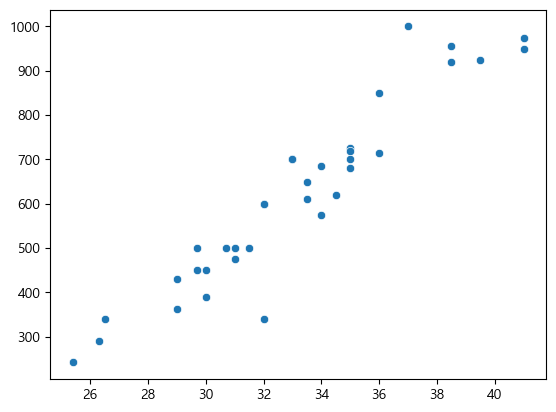

In [15]:
# bream: (도미총 35개)
# ['Breame', 'Roach', 'Whitefish', 'Parkki', 'Perch', 'Pike', 'Smelt']
bream_length = list(fish_df[fish_df["Species"] == "Bream"]["Length"])
bream_Weight = list(fish_df[fish_df["Species"] == "Bream"]["Weight"])

# 선형데이터 ㄴㄴ
sns.scatterplot(x=bream_length, y=bream_Weight)
plt.show()

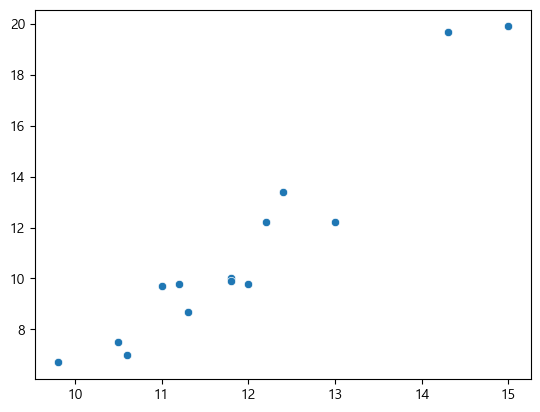

In [16]:
# Smelt: 빙어(총 14개)
# ['Bream', 'Roach', 'Whitefish', 'Parkki', 'Perch', 'Pike', 'Smelt']
smelt_length = list(fish_df[fish_df["Species"] == "Smelt"]["Length"])
smelt_Weight = list(fish_df[fish_df["Species"] == "Smelt"]["Weight"])

# 선형데이터ㄴ
sns.scatterplot(x=smelt_length, y=smelt_Weight)
plt.show()

In [17]:
fish_df = fish_df[fish_df["Species"].isin(["Bream", "Smelt"])]

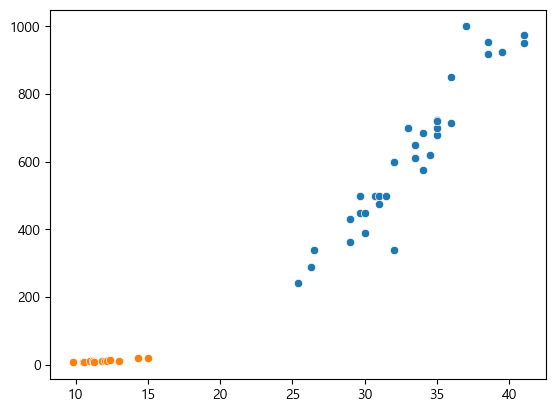

In [18]:
sns.scatterplot(x=bream_length, y=bream_Weight)
sns.scatterplot(x=smelt_length, y=smelt_Weight)
plt.show()

In [19]:
fish_df.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


## 분류형 데이터 인코딩

In [20]:
# fish_df["Species"].map(lambda specie: {"Bream": 0, "Smelt": 1}[specie])

# 참조형
fish_df["Species"] = fish_df["Species"].map({"Bream": 0, "Smelt": 1})

In [21]:
fish_df.head()

,Species,Weight,Length,Diagonal,Height,Width
0,0,242.0,25.4,30.0,11.5200,4.0200
1,0,290.0,26.3,31.2,12.4800,4.3056
2,0,340.0,26.5,31.1,12.3778,4.6961
3,0,363.0,29.0,33.5,12.7300,4.4555
4,0,430.0,29.0,34.0,12.4440,5.1340


## 1단계, 데이터 준비(탐색)

In [22]:
# 데이터 탐색: info -> 데이터의 컬럼이나 데이터의 값들이 뭐가 들어갔는지 확인

fish_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49 entries, 0 to 158
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Species   49 non-null     int64  
 1   Weight    49 non-null     float64
 2   Length    49 non-null     float64
 3   Diagonal  49 non-null     float64
 4   Height    49 non-null     float64
 5   Width     49 non-null     float64
dtypes: float64(5), int64(1)
memory usage: 2.7 KB


In [23]:
fish_df = fish_df.drop(["Diagonal", "Height", "Width"], axis=1)
fish_df.head()

,Species,Weight,Length
0,0,242.0,25.4
1,0,290.0,26.3
2,0,340.0,26.5
3,0,363.0,29.0
4,0,430.0,29.0


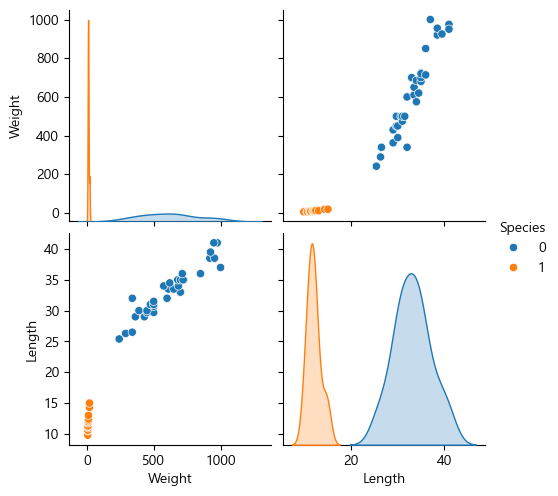

In [24]:
sns.pairplot(fish_df, hue="Species")
plt.show()

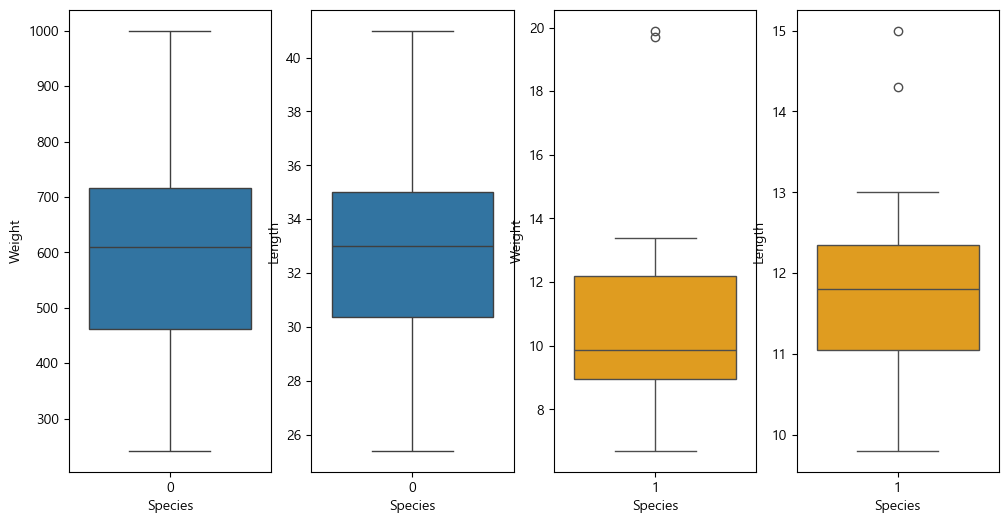

In [25]:
pig, axes = plt.subplots(1, 4, figsize=(12, 6))
sns.boxplot(fish_df[fish_df["Species"] == 0], x="Species", y="Weight", ax=axes[0])
sns.boxplot(fish_df[fish_df["Species"] == 0], x="Species", y="Length", ax=axes[1])
sns.boxplot(fish_df[fish_df["Species"] == 1], x="Species", y="Weight", ax=axes[2], color="orange")
sns.boxplot(fish_df[fish_df["Species"] == 1], x="Species", y="Length", ax=axes[3], color="orange")
plt.show()

## 2단계, 데이터 분할

In [26]:
# 독립 변수, 종속 변수

In [27]:
X = fish_df.drop("Species", axis=1)
X.head()

,Weight,Length
0,242.0,25.4
1,290.0,26.3
2,340.0,26.5
3,363.0,29.0
4,430.0,29.0


In [28]:
y = fish_df["Species"]
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Species, dtype: int64

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2026, stratify=y)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(39, 2) (10, 2) (39,) (10,)


## 3단계 모델준비

### KNN (k-최근접 이웃, k-Neighbors) 알고리즘
- 어떤 데이터에 대한 답을 구할떄 주변의 다른 데이터를 보고 다술르 차지하는 데이터를 정답으로 ㄱ려정한느 방식의 알고리즘
### KNN 장점
- 데이터만 있으면 알고리즘을 사용할 수 있다
### KNN 단점
- 데이터가 많으면 사용하지 힘들며 많은 메모리를 사용한다

In [30]:
from sklearn.neighbors import KNeighborsClassifier

kn = KNeighborsClassifier()

## 4단계, 모델 학습

In [31]:
kn.fit(X_train, y_train)

KNeighborsClassifier()

## 5단계, 모델 예측

In [64]:
y_pred = kn.predict(X_test)
print(y_pred)
print(list(y_test))

[0 1 0 0 0 0 0 1 1 0]
[0, 1, 0, 0, 0, 0, 0, 1, 1, 0]


## 6단계, 모델 평가

In [65]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix,ConfusionMatrixDisplay

In [66]:
print(f"accuracy_score: {accuracy_score(y_test, y_pred)}")

accuracy_score: 1.0


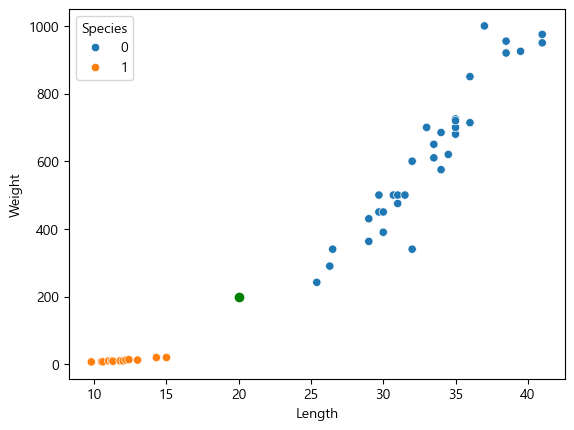

In [67]:
sns.scatterplot(fish_df, x="Length", y="Weight", hue="Species")
plt.scatter(20, 200, color = "green")
plt.show()

In [68]:
columns = X_train.columns
new_data = pd.DataFrame([[20,200]], columns=columns)
new_data

,Weight,Length
0,20,200


In [69]:
neighbors = X_train.iloc[indexes[0]]
neighbors

,Weight,Length
158,19.9,15.0
157,19.7,14.3
156,12.2,13.0
155,13.4,12.4
152,9.9,11.8


In [74]:
distance, indexes = kn.kneighbors(new_data)
print(distance, indexes)

[[185.00002703 185.70024233 187.1626031  187.71606218 188.47082002]] [[32 35 10  6  4]]


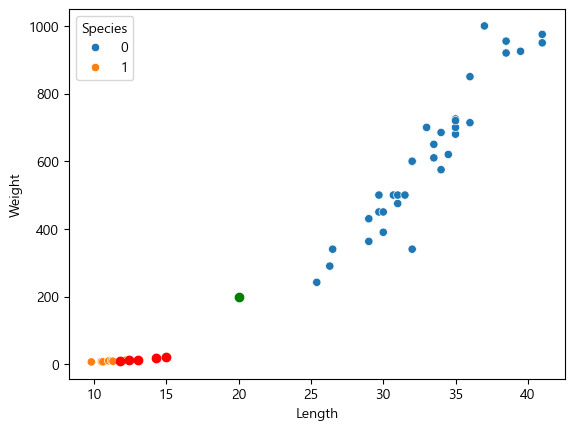

In [75]:
sns.scatterplot(fish_df, x="Length", y="Weight", hue="Species")
plt.scatter(20, 200, color="green")
plt.scatter(neighbors["Length"], neighbors["Weight"], color="red")
plt.show()

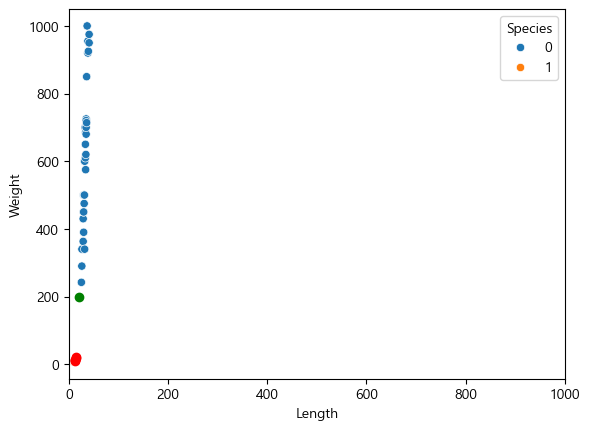

In [76]:
sns.scatterplot(fish_df, x="Length", y="Weight", hue="Species")
plt.scatter(20, 200, color = "green")
plt.scatter(neighbors["Length"], neighbors["Weight"], color="red")
plt.xlim(0, 1000)
plt.show()

In [85]:
# StandardScaler 표준화
from sklearn.preprocessing import StandardScaler

# (데이터 값 - 평균) / 표준편차
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [100]:
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)
print(mean)
print(std)


Weight    453.935897
Length     27.158974
dtype: float64
Weight    327.314297
Length     10.150122
dtype: float64


In [101]:
X_train_scaled_df = (X_train - mean) / std
X_train_scaled_df["Species"] = y_train
X_train_scaled_df.head()

,Weight,Length,Species
32,1.439180,1.215850,0
17,0.751767,0.575464,0
145,-1.366381,-1.710223,1
21,0.705940,0.673985,0
152,-1.356604,-1.513181,1


In [102]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=columns)
X_train_scaled_df["Species"] = y_train
X_train_scaled_df

,Weight,Length,Species
0,1.439180,1.215850,0.0
1,0.751767,0.575464,NaN
2,-1.366381,-1.710223,0.0
3,0.705940,0.673985,0.0
4,-1.356604,-1.513181,0.0
5,-1.365464,-1.631406,0.0
6,-1.345911,-1.454069,NaN
7,0.828146,0.772506,0.0
8,-1.360270,-1.562442,0.0
9,0.507354,0.723245,0.0


In [103]:
new_data_scaled = (new_data - mean) / std
new_data_scaled

,Weight,Length
0,-1.325747,17.028467


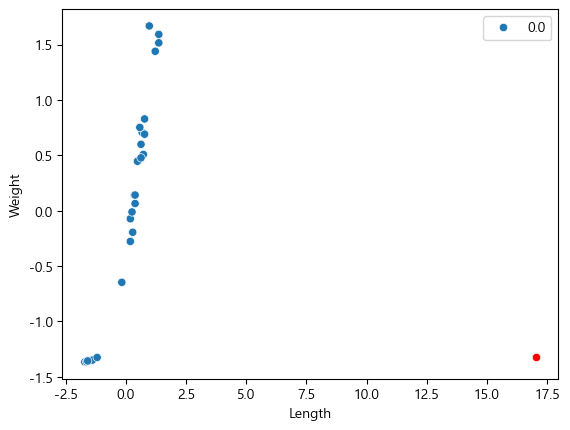

In [105]:
sns.scatterplot(X_train_scaled_df, x="Length", y="Weight", hue="Species")
sns.scatterplot(new_data_scaled, x="Length", y="Weight", color="red")
plt.show()

In [110]:
# 모델학습
kn.fit(X_train_scaled,y_train)

KNeighborsClassifier()

In [111]:
# 모델평가
accuracy_score(y_pred, y_test)

1.0

In [112]:
# 혼동행렬
cm = confusion_matrix(y_test, y_pred)
cm

array([[7, 0],
       [0, 3]], dtype=int64)

In [113]:
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["도미(0)", "빙어(1)"])
display.plot(camp="Blues")
plt.title("혼동행렬")
plt.show()

TypeError: ConfusionMatrixDisplay.plot() got an unexpected keyword argument 'camp'